In [3]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [5]:
import matplotlib.font_manager as fm
for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    print(f)

C:\Windows\Fonts\symbol.ttf
C:\Windows\Fonts\trebucit.ttf
C:\Windows\Fonts\CALIFB.TTF
C:\Windows\Fonts\TCB_____.TTF
C:\Windows\Fonts\LEELAWAD.TTF
C:\Windows\Fonts\seguihis.ttf
C:\Windows\Fonts\segoeuii.ttf
C:\Windows\Fonts\LFAXI.TTF
C:\Windows\Fonts\PERTILI.TTF
C:\Windows\Fonts\Mathe.ttf
C:\Windows\Fonts\timesbi.ttf
C:\Windows\Fonts\BOD_CBI.TTF
C:\Windows\Fonts\YuGothR.ttc
C:\Windows\Fonts\GOTHICI.TTF
C:\Windows\Fonts\GILBI___.TTF
C:\Windows\Fonts\HTOWERT.TTF
C:\Windows\Fonts\ITCKRIST.TTF
C:\Windows\Fonts\arialbd.ttf
C:\Windows\Fonts\SitkaZ.ttc
C:\Windows\Fonts\SymbM.ttf
C:\Windows\Fonts\segoesc.ttf
C:\Windows\Fonts\tahoma.ttf
C:\Windows\Fonts\courbi.ttf
C:\Windows\Fonts\cambriaz.ttf
C:\Windows\Fonts\segoepr.ttf
C:\Windows\Fonts\ELEPHNTI.TTF
C:\Windows\Fonts\BOD_I.TTF
C:\Windows\Fonts\OUTLOOK.TTF
C:\Windows\Fonts\GIL_____.TTF
C:\Windows\Fonts\GOUDOS.TTF
C:\Windows\Fonts\HATTEN.TTF
C:\Windows\Fonts\KUNSTLER.TTF
C:\Windows\Fonts\CALISTI.TTF
C:\Windows\Fonts\LBRITED.TTF
C:\Windows\Fonts\c

findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font famil

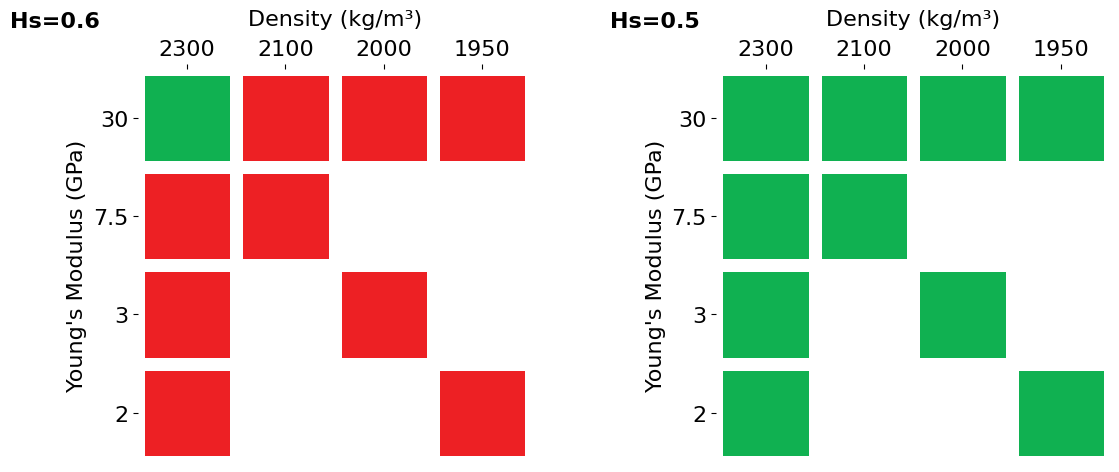

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import copy
from matplotlib.colors import LinearSegmentedColormap

# Set figure and axes background colors to white
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Set STIX font and math support, with fontsize 16
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 16

# Young's modulus values (rows)
youngs_modulus_values = [2, 3, 7.5, 30]  # in GPa

# Density values (columns)
density_values = [2300, 2100, 2000, 1950]  # in kg/m³

# First matrix
results_matrix1 = np.array([
    [1, 0.0, 0.0, 1],
    [1, 0.0, 1, 0.0],
    [1, 1, 0.0, 0.0],
    [0.01, 1, 1, 1]
])

# Second matrix
results_matrix2 = np.array([
    [0.01, 0.0, 0.0, 0.01],
    [0.01, 0.0, 0.01, 0.0],
    [0.01, 0.01, 0.0, 0.0],
    [0.01, 0.01, 0.01, 0.01]
])

# Function to plot one matrix on a given axis
def plot_matrix(ax, matrix, density_values, youngs_modulus_values, cmap, opacity):
    # Mask zero values
    masked_matrix = np.ma.masked_where(matrix == 0, matrix)

    # Create grid edges
    x_edges = np.arange(len(density_values) + 1)
    y_edges = np.arange(len(youngs_modulus_values) + 1)

    # Plot with pcolormesh
    c = ax.pcolormesh(
        x_edges,
        y_edges,
        masked_matrix,
        cmap=cmap,
        edgecolors='white',
        linewidth=8,
        alpha=opacity
    )

    # Center ticks on squares
    ax.set_xticks(np.arange(len(density_values)) + 0.5)
    ax.set_yticks(np.arange(len(youngs_modulus_values)) + 0.5)

    # Set tick labels
    ax.set_xticklabels(density_values)
    ax.set_yticklabels(youngs_modulus_values)

    # Move x-axis to top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Instead of set_xlabel, plot text higher above the axis
    ax.text(
        0.5, 1.1,
        'Density (kg/m³)',
        transform=ax.transAxes,
        ha='center',
        va='bottom'
    )

    # Set y-axis label as usual
    ax.set_ylabel("Young's Modulus (GPa)")

    # Force squares
    ax.set_aspect('equal')

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    return c

# Create custom colormap from green to red
custom_cmap = LinearSegmentedColormap.from_list(
    'green_red',
    ['#10b151', '#ed2024']
)

# For older matplotlib, make a copy and set bad color
cmap = copy.copy(custom_cmap)
cmap.set_bad(color='white')

# Opacity
opacity = 1.0

# Create figure and two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot first matrix
plot_matrix(
    axes[0],
    results_matrix1,
    density_values,
    youngs_modulus_values,
    cmap,
    opacity
)

# Plot second matrix
plot_matrix(
    axes[1],
    results_matrix2,
    density_values,
    youngs_modulus_values,
    cmap,
    opacity
)

# Add figure-level text in the top-left corner
fig.text(
    0.01, 0.95,
    "Hs=0.6",
    ha='left',
    va='top',
    fontsize=16,
    fontweight='bold',
    color='black'
)

# Add figure-level text in the top-middle
fig.text(
    0.51, 0.95,
    "Hs=0.5",
    ha='left',
    va='top',
    fontsize=16,
    fontweight='bold',
    color='black'
)

plt.tight_layout()
plt.show()
